## Import Library & Load Model

In [1]:
import os
import json
import shutil
import platform
import numpy as np
import pandas as pd
import optuna

SEED = 42
np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"optuna : {optuna.__version__}")
print(f"random seed : {SEED}")

NB4_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook04a"
stage1_df = pd.read_csv(f"{NB4_DIR}/nb4_topsis_stage1.csv")
print(f"\n{len(stage1_df)} konfigurasi terpilih dimuat dari nb4_topsis_stage1.csv")
print(stage1_df[["model", "trial", "step", "f1", "avg_time_s", "size", "closeness"]].to_string(index=False))

python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3
optuna : 4.9.0
random seed : 42

6 konfigurasi terpilih dimuat dari nb4_topsis_stage1.csv
        model  trial  step       f1  avg_time_s     size  closeness
Decision Tree     28    10 0.918919   17.129630    137.0   0.624904
     LightGBM     67     5 0.959276   17.847222    162.0   0.725280
      XGBoost     60     5 0.953704   13.518519    390.0   0.682106
          TCN     14    10 0.925110   30.000000   8833.0   0.786068
          GRU     41     5 0.899160   13.055556  42305.0   0.630980
     CNN-LSTM      3     5 0.929204   14.629630 215713.0   0.823446


## Ambil Parameter Model

In [2]:
MODEL_NAMES = ["Decision Tree", "LightGBM", "XGBoost", "TCN", "GRU", "CNN-LSTM"]
SLUGS = {name: name.replace(" ", "_").replace("-", "").lower() for name in MODEL_NAMES}

for name in MODEL_NAMES:
    slug = SLUGS[name]
    src_path = f"{NB4_DIR}/optuna_{slug}.db"
    dst_path = f"/kaggle/working/optuna_{slug}.db"
    if not os.path.exists(dst_path):
        shutil.copy(src_path, dst_path)

selected_params = {}
for _, row in stage1_df.iterrows():
    name = row["model"]
    trial_number = int(row["trial"])
    slug = SLUGS[name]
    storage_path = f"sqlite:////kaggle/working/optuna_{slug}.db"
    study = optuna.load_study(study_name=name, storage=storage_path)
    trial = next(t for t in study.trials if t.number == trial_number)
    selected_params[name] = trial.params

    f1_v, time_v, size_v = trial.values
    print(f"\n{'=' * 70}\n{name} -- trial {trial_number}\n{'=' * 70}")
    ok = (abs(f1_v - row.f1) < 1e-6 and abs(time_v - row.avg_time_s) < 1e-6 and abs(size_v - row["size"]) < 1e-6)
    tag = "[OK]" if ok else "[BEDA -- CEK ULANG]"
    print(f"  cek silang {tag}: f1={f1_v:.4f} (csv={row.f1:.4f}), "
          f"avg_time_s={time_v:.4f} (csv={row.avg_time_s:.4f}), "
          f"size={size_v:.0f} (csv={row['size']:.0f})")
    for k, v in trial.params.items():
        print(f"  {k:22s}: {v}")

with open("/kaggle/working/nb4a_selected_hparams.json", "w") as f:
    json.dump(selected_params, f, indent=2)
print("\nDisimpan: nb4a_selected_hparams.json")


Decision Tree -- trial 28
  cek silang [OK]: f1=0.9189 (csv=0.9189), avg_time_s=17.1296 (csv=17.1296), size=137 (csv=137)
  step                  : 10
  dtree_max_depth       : 18
  dtree_min_samples_leaf: 16
  economy_K             : 6
  economy_alpha         : 0.0021705003488711127
  economy_beta          : 1.8819251105233787

LightGBM -- trial 67
  cek silang [OK]: f1=0.9593 (csv=0.9593), avg_time_s=17.8472 (csv=17.8472), size=162 (csv=162)
  step                  : 5
  lgbm_n_estimators     : 27
  lgbm_max_depth        : 6
  lgbm_learning_rate    : 0.1018213577190286
  lgbm_num_leaves       : 11
  lgbm_subsample        : 0.9936380646574723
  economy_K             : 5
  economy_alpha         : 0.014001191914113755
  economy_beta          : 1.8011661899141396

XGBoost -- trial 60
  cek silang [OK]: f1=0.9537 (csv=0.9537), avg_time_s=13.5185 (csv=13.5185), size=390 (csv=390)
  step                  : 5
  xgb_n_estimators      : 65
  xgb_max_depth         : 10
  xgb_learning_rate     

## Load Data & Define Fungsi

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

NB2_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02"
features = pd.read_csv(f"{NB2_DIR}/features_gold.csv")
split = pd.read_csv(f"{NB2_DIR}/split_assignment.csv")

train_rows = split[split.split == "train"].copy()
fit_rows, calib_rows = train_test_split(
    train_rows, test_size=0.20, stratify=train_rows["class"], random_state=SEED
)
fit_paths = fit_rows["path"]
calib_paths = calib_rows["path"]
val_paths = split.loc[split.split == "val", "path"]

print(f"train_fit   : {len(fit_paths)} eksekusi")
print(f"train_calib : {len(calib_paths)} eksekusi")
print(f"val         : {len(val_paths)} eksekusi")

STORAGE_FEATURE_NAMES = ["T_s_r", "T_s_w", "V_s_r", "V_s_w", "H_s_w"]
MEMORY_FEATURE_NAMES = (
    ["H_m_w", "H_m_rw"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
ALL_FEATURE_NAMES = STORAGE_FEATURE_NAMES + MEMORY_FEATURE_NAMES
FEATURE_COLUMNS_FULL = ALL_FEATURE_NAMES + ["w"]

LOG1P_FEATURES = (
    ["T_s_r", "T_s_w", "V_s_r", "V_s_w"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
LOG1P_IDX = [FEATURE_COLUMNS_FULL.index(f) for f in LOG1P_FEATURES]


def checkpoints_for_step(step, max_w=30):
    return list(range(step, max_w + 1, step))


def build_sequences(df, paths, checkpoint_grid, feature_names):
    sub = df[df["path"].isin(paths) & df["window_s"].isin(checkpoint_grid)]
    sequences, labels = [], []
    for path, g in sub.groupby("path", sort=False):
        g = g.sort_values("window_s")
        assert len(g) == len(checkpoint_grid)
        w = g["window_s"].to_numpy(dtype="float64")
        feat = g[feature_names].to_numpy(dtype="float64")
        sequences.append(np.concatenate([feat, w[:, None]], axis=1))
        labels.append(int(g["is_ransomware"].iloc[0]))
    X = np.stack(sequences).astype("float32")
    y = np.array(labels, dtype="int32")
    return X, y


def apply_log1p(X, idx):
    X = X.copy()
    X[..., idx] = np.log1p(np.clip(X[..., idx], a_min=0.0, a_max=None))
    return X


def scale_3d(X, scaler):
    shp = X.shape
    return scaler.transform(X.reshape(-1, shp[-1])).reshape(shp).astype("float32")


def prepare_split_data(step):
    grid = checkpoints_for_step(step)
    X_fit_raw, y_fit = build_sequences(features, fit_paths, grid, ALL_FEATURE_NAMES)
    X_calib_raw, y_calib = build_sequences(features, calib_paths, grid, ALL_FEATURE_NAMES)
    X_val_raw, y_val = build_sequences(features, val_paths, grid, ALL_FEATURE_NAMES)

    X_fit_log = apply_log1p(X_fit_raw, LOG1P_IDX)
    X_calib_log = apply_log1p(X_calib_raw, LOG1P_IDX)
    X_val_log = apply_log1p(X_val_raw, LOG1P_IDX)
    scaler = StandardScaler().fit(X_fit_log.reshape(-1, X_fit_log.shape[-1]))

    X_fit = scale_3d(X_fit_log, scaler)
    X_calib = scale_3d(X_calib_log, scaler)
    X_val = scale_3d(X_val_log, scaler)
    return grid, X_fit, y_fit, X_calib, y_calib, X_val, y_val


def cost_sensitive_predict(p, beta):
    threshold = 1.0 / (1.0 + beta)
    return (p > threshold).astype(int)


def build_economy_table(calib_probs, calib_y, K, beta):
    n_calib, M = calib_probs.shape
    bin_edges = np.zeros((M, K - 1))
    group_idx = np.zeros((n_calib, M), dtype=int)

    for i in range(M):
        edges = np.quantile(calib_probs[:, i], np.linspace(0, 1, K + 1)[1:-1])
        bin_edges[i] = edges
        gi = np.searchsorted(edges, calib_probs[:, i], side="right")
        group_idx[:, i] = np.clip(gi, 0, K - 1)

    hard_pred = cost_sensitive_predict(calib_probs, beta)

    prior1, fp_rate, fn_rate = {}, {}, {}
    for i in range(M):
        for k in range(K):
            mask_ik = group_idx[:, i] == k
            n_ik = mask_ik.sum()
            if n_ik == 0:
                prior1[(i, k)] = 0.5
                for j in range(i, M):
                    fp_rate[(i, j, k)] = 0.5
                    fn_rate[(i, j, k)] = 0.5
                continue
            y_ik = calib_y[mask_ik]
            prior1[(i, k)] = y_ik.mean()

            benign_mask = mask_ik & (calib_y == 0)
            ransom_mask = mask_ik & (calib_y == 1)
            n_benign, n_ransom = benign_mask.sum(), ransom_mask.sum()

            for j in range(i, M):
                fp_rate[(i, j, k)] = hard_pred[benign_mask, j].mean() if n_benign > 0 else 0.5
                fn_rate[(i, j, k)] = 1.0 - hard_pred[ransom_mask, j].mean() if n_ransom > 0 else 0.5

    return bin_edges, prior1, fp_rate, fn_rate


def simulate_decisions(probs, checkpoint_grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta, T_max=30.0):
    n_samples, M = probs.shape
    y_pred = np.zeros(n_samples, dtype=int)
    decision_time = np.zeros(n_samples)

    for s in range(n_samples):
        for i in range(M):
            p_i = probs[s, i]
            k = int(np.clip(np.searchsorted(bin_edges[i], p_i, side="right"), 0, len(bin_edges[i])))
            best_tau, best_cost = 0, np.inf
            pr1 = prior1[(i, k)]
            pr0 = 1.0 - pr1
            for j in range(i, M):
                cost_now = pr0 * fp_rate[(i, j, k)] * 1.0 + pr1 * fn_rate[(i, j, k)] * beta
                cd = alpha * (checkpoint_grid[j] / T_max)
                total = cost_now + cd
                if total < best_cost:
                    best_cost, best_tau = total, j - i
            if best_tau == 0 or i == M - 1:
                y_pred[s] = 1 if p_i > (1.0 / (1.0 + beta)) else 0
                decision_time[s] = checkpoint_grid[i]
                break
    return y_pred, decision_time


def economy_objectives_fixed(probs_calib, y_calib, probs_val, y_val, checkpoint_grid, K, alpha, beta):
    bin_edges, prior1, fp_rate, fn_rate = build_economy_table(probs_calib, y_calib, K, beta)
    y_pred, dtime = simulate_decisions(probs_val, checkpoint_grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    return f1, float(dtime.mean())

train_fit   : 805 eksekusi
train_calib : 202 eksekusi
val         : 216 eksekusi


## Retrain ML

In [4]:
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
import xgboost as xgb

CLASSICAL_MODELS = ["Decision Tree", "LightGBM", "XGBoost"]
trained_classical = {}

for name in CLASSICAL_MODELS:
    params = selected_params[name]
    step = params["step"]
    grid, X_fit, y_fit, X_calib, y_calib, X_val, y_val = prepare_split_data(step)

    if name == "Decision Tree":
        hp = {"max_depth": params["dtree_max_depth"], "min_samples_leaf": params["dtree_min_samples_leaf"]}
    elif name == "LightGBM":
        hp = {"n_estimators": params["lgbm_n_estimators"], "max_depth": params["lgbm_max_depth"],
              "learning_rate": params["lgbm_learning_rate"], "num_leaves": params["lgbm_num_leaves"],
              "subsample": params["lgbm_subsample"]}
    else:
        hp = {"n_estimators": params["xgb_n_estimators"], "max_depth": params["xgb_max_depth"],
              "learning_rate": params["xgb_learning_rate"], "subsample": params["xgb_subsample"]}

    models_per_ckpt = []
    for i in range(len(grid)):
        if name == "Decision Tree":
            m = DecisionTreeClassifier(random_state=SEED, **hp)
        elif name == "LightGBM":
            m = lgb.LGBMClassifier(random_state=SEED, verbose=-1, **hp)
        else:
            m = xgb.XGBClassifier(random_state=SEED, eval_metric="logloss", **hp)
        m.fit(X_fit[:, i, :], y_fit)
        models_per_ckpt.append(m)

    probs_calib = np.stack([m.predict_proba(X_calib[:, i, :])[:, 1] for i, m in enumerate(models_per_ckpt)], axis=1)
    probs_val = np.stack([m.predict_proba(X_val[:, i, :])[:, 1] for i, m in enumerate(models_per_ckpt)], axis=1)

    f1, avg_time = economy_objectives_fixed(
        probs_calib, y_calib, probs_val, y_val, grid,
        params["economy_K"], params["economy_alpha"], params["economy_beta"],
    )

    if name == "Decision Tree":
        size = int(sum(m.tree_.node_count for m in models_per_ckpt))
    elif name == "LightGBM":
        size = int(sum(m.booster_.num_trees() for m in models_per_ckpt))
    else:
        size = int(sum(m.get_booster().num_boosted_rounds() for m in models_per_ckpt))

    trained_classical[name] = {"models_per_ckpt": models_per_ckpt, "grid": grid, "step": step}

    print(
        f"{name:14s} trained | "
        f"checkpoints={len(models_per_ckpt)} | "
        f"internal_size={size} | "
        f"step={step}"
    )



print("\nModel klasik terlatih:", list(trained_classical.keys()))


Decision Tree  trained | checkpoints=3 | internal_size=137 | step=10


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM       trained | checkpoints=6 | internal_size=162 | step=5
XGBoost        trained | checkpoints=6 | internal_size=390 | step=5

Model klasik terlatih: ['Decision Tree', 'LightGBM', 'XGBoost']


## Retrain DL

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def _tcn_residual_block(x, filters, kernel_size, dilation_rate):
    prev = x
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(h)
    if prev.shape[-1] != filters:
        prev = layers.Conv1D(filters, 1, padding="same")(prev)
    return layers.Add()([prev, h])


def build_tcn_hpo(seq_len, n_features, filters, kernel_size, dilations, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for d in dilations:
        x = _tcn_residual_block(x, filters, kernel_size, d)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="tcn")


def build_gru_hpo(seq_len, n_features, units, n_layers, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for _ in range(n_layers):
        x = layers.GRU(units, return_sequences=True)(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="gru")


def build_cnn_lstm_hpo(seq_len, n_features, conv_filters, kernel_size, lstm_units, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(filters=conv_filters, kernel_size=kernel_size, padding="causal", activation="linear")(inputs)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="cnn_lstm_modified")


DL_MODELS = ["TCN", "GRU", "CNN-LSTM"]
trained_dl = {}

for name in DL_MODELS:
    params = selected_params[name]
    step = params["step"]
    grid, X_fit, y_fit, X_calib, y_calib, X_val, y_val = prepare_split_data(step)

    y_fit_seq = np.repeat(y_fit[:, None, None], len(grid), axis=1).astype("float32")
    y_calib_seq = np.repeat(y_calib[:, None, None], len(grid), axis=1).astype("float32")

    keras.utils.set_random_seed(SEED)
    if name == "TCN":
        dilations = tuple(2 ** i for i in range(params["tcn_n_blocks"]))
        model = build_tcn_hpo(len(grid), X_fit.shape[-1], params["tcn_filters"],
                               params["tcn_kernel_size"], dilations, params["tcn_dropout"])
        lr = params["tcn_lr"]
    elif name == "GRU":
        model = build_gru_hpo(len(grid), X_fit.shape[-1], params["gru_units"],
                               params["gru_n_layers"], params["gru_dropout"])
        lr = params["gru_lr"]
    else:
        model = build_cnn_lstm_hpo(len(grid), X_fit.shape[-1], params["cnnlstm_conv_filters"],
                                    params["cnnlstm_kernel_size"], params["cnnlstm_lstm_units"],
                                    params["cnnlstm_dropout"])
        lr = params["cnnlstm_lr"]

    model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy")
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    model.fit(X_fit, y_fit_seq, validation_data=(X_calib, y_calib_seq),
              epochs=50, batch_size=32, callbacks=[es], verbose=0)

    probs_calib = model.predict(X_calib, verbose=0)[:, :, 0]
    probs_val = model.predict(X_val, verbose=0)[:, :, 0]

    f1, avg_time = economy_objectives_fixed(
        probs_calib, y_calib, probs_val, y_val, grid,
        params["economy_K"], params["economy_alpha"], params["economy_beta"],
    )
    size = model.count_params()

    trained_dl[name] = {"model": model, "grid": grid, "step": step}

    print(
        f"{name:14s} trained | "
        f"params={model.count_params():,} | "
        f"step={step}"
    )

print("\nModel DL terlatih:", list(trained_dl.keys()))

I0000 00:00:1789918137.589417      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789918137.592462      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1789918147.416996      75 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


TCN            trained | params=8,833 | step=10
GRU            trained | params=42,305 | step=5
CNN-LSTM       trained | params=215,713 | step=5

Model DL terlatih: ['TCN', 'GRU', 'CNN-LSTM']


In [6]:
!pip install -q tf2onnx skl2onnx onnxmltools onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 73.1 MB/s eta 0:00:00


In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tf2onnx
import onnxruntime as ort
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from onnxmltools.convert import convert_lightgbm, convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType as OMLFloatTensorType

ONNX_DIR = "/kaggle/working/onnx_models"
os.makedirs(ONNX_DIR, exist_ok=True)
onnx_sizes_kb = {}
onnx_verified = {}

CLASSICAL_CONVERTERS = {
    "Decision Tree": lambda m, it: convert_sklearn(m, initial_types=it, options={id(m): {"zipmap": False}}),
    "LightGBM": lambda m, it: convert_lightgbm(m, initial_types=it, zipmap=False),
    "XGBoost": lambda m, it: convert_xgboost(m, initial_types=it),
}

for name, converter in CLASSICAL_CONVERTERS.items():
    info = trained_classical[name]
    models_per_ckpt, grid, step = info["models_per_ckpt"], info["grid"], info["step"]
    _, _, _, _, _, X_val, _ = prepare_split_data(step)
    x_sample = X_val[:5]

    TensorType = FloatTensorType if name == "Decision Tree" else OMLFloatTensorType
    total_bytes = 0
    max_diff = 0.0
    for i, m in enumerate(models_per_ckpt):
        initial_type = [("input", TensorType([None, m.n_features_in_]))]
        onnx_model = converter(m, initial_type)
        path = f"{ONNX_DIR}/{name.replace(' ', '_')}_ckpt{i}.onnx"
        with open(path, "wb") as f:
            f.write(onnx_model.SerializeToString())
        total_bytes += os.path.getsize(path)

        sess = ort.InferenceSession(path)
        onnx_prob = sess.run(None, {sess.get_inputs()[0].name: x_sample[:, i, :]})[1][:, 1]
        native_prob = m.predict_proba(x_sample[:, i, :])[:, 1]
        max_diff = max(max_diff, float(np.abs(onnx_prob - native_prob).max()))

    onnx_sizes_kb[name] = total_bytes / 1024
    onnx_verified[name] = (max_diff < 1e-5)

    print(
        f"{name:14s} [OK]: {len(models_per_ckpt)} file ONNX, "
        f"total {onnx_sizes_kb[name]:.2f} KB, "
        f"selisih maks vs model asli={max_diff:.2e}"
    )


def build_gru_export(seq_len, n_features, units, n_layers, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for _ in range(n_layers):
        x = layers.GRU(units, return_sequences=True, unroll=True)(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs)


def build_cnn_lstm_export(seq_len, n_features, conv_filters, kernel_size, lstm_units, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(filters=conv_filters, kernel_size=kernel_size, padding="causal", activation="linear")(inputs)
    x = layers.LSTM(lstm_units, return_sequences=True, unroll=True)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units, return_sequences=True, unroll=True)(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs)


for name in ["TCN", "GRU", "CNN-LSTM"]:
    info = trained_dl[name]
    model, step = info["model"], info["step"]
    _, _, _, _, _, X_val, _ = prepare_split_data(step)
    x_sample = X_val[:5]
    seq_len, n_features = model.input_shape[1], model.input_shape[2]
    params = selected_params[name]

    if name == "GRU":
        export_model = build_gru_export(seq_len, n_features, params["gru_units"],
                                         params["gru_n_layers"], params["gru_dropout"])
        export_model.set_weights(model.get_weights())
    elif name == "CNN-LSTM":
        export_model = build_cnn_lstm_export(seq_len, n_features, params["cnnlstm_conv_filters"],
                                              params["cnnlstm_kernel_size"], params["cnnlstm_lstm_units"],
                                              params["cnnlstm_dropout"])
        export_model.set_weights(model.get_weights())
    else:
        export_model = model 

    spec = (tf.TensorSpec((None, seq_len, n_features), tf.float32, name="input"),)
    path = f"{ONNX_DIR}/{name.replace('-', '_')}.onnx"
    tf2onnx.convert.from_keras(export_model, input_signature=spec, output_path=path)
    onnx_sizes_kb[name] = os.path.getsize(path) / 1024
    onnx_verified[name] = (max_diff < 1e-5)

    sess = ort.InferenceSession(path)
    onnx_out = sess.run(None, {sess.get_inputs()[0].name: x_sample})[0]
    keras_out = model.predict(x_sample, verbose=0) 
    max_diff = float(np.abs(onnx_out - keras_out).max())
    onnx_verified[name] = (max_diff < 1e-5)
    print(f"{name:14s} {tag}: 1 file ONNX, {onnx_sizes_kb[name]:.2f} KB, selisih maks vs Keras={max_diff:.2e}")

print("\nRingkasan ukuran ONNX (KB):")
for name in MODEL_NAMES:
    print(f"  {name:14s}: {onnx_sizes_kb[name]:8.2f} KB ")

onnx_sizes_df = pd.DataFrame(
    [{"model": k, "onnx_kb": onnx_sizes_kb[k], "terverifikasi": onnx_verified[k]} for k in MODEL_NAMES]
)
onnx_sizes_df.to_csv("/kaggle/working/nb4a_onnx_sizes.csv", index=False)
print("\nDisimpan: nb4a_onnx_sizes.csv")

Decision Tree  [OK]: 3 file ONNX, total 6.67 KB, selisih maks vs model asli=2.29e-08


2026-09-20 15:29:53.059676576 [W:onnxruntime:, execution_frame.cc:905 VerifyOutputSizes] Expected shape from model of {1} does not match actual shape of {5} for output label
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026-09-20 15:29:53.076110234 [W:onnxruntime:, execution_frame.cc:905 VerifyOutputSizes] Expected shape from model of {1} does not match actual shape of {5} for output label
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026-09-20 15:29:53.090814581 [W:onnxruntime:, execution_frame.cc:905 VerifyOutputSizes] Expected shape from model of {1} does not match actual shape of {5} for output label
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not 

LightGBM       [OK]: 6 file ONNX, total 126.54 KB, selisih maks vs model asli=5.94e-08
XGBoost        [OK]: 6 file ONNX, total 649.27 KB, selisih maks vs model asli=6.71e-08


I0000 00:00:1789918195.686752      23 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789918195.687069      23 single_machine.cc:376] Starting new session
I0000 00:00:1789918195.701992      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789918195.703647      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1789918195.839073      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789918195.840760      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 M

TCN            [OK]: 1 file ONNX, 45.29 KB, selisih maks vs Keras=3.28e-07


I0000 00:00:1789918197.901808      23 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789918197.901994      23 single_machine.cc:376] Starting new session
I0000 00:00:1789918197.916799      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789918197.918435      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1789918198.230125      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789918198.231785      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 M

GRU            [OK]: 1 file ONNX, 220.53 KB, selisih maks vs Keras=5.96e-08


I0000 00:00:1789918200.715866      23 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1789918200.716034      23 single_machine.cc:376] Starting new session
I0000 00:00:1789918200.730808      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789918200.732435      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1789918200.949322      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789918200.950969      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 M

CNN-LSTM       [OK]: 1 file ONNX, 890.24 KB, selisih maks vs Keras=1.79e-07

Ringkasan ukuran ONNX (KB):
  Decision Tree :     6.67 KB 
  LightGBM      :   126.54 KB 
  XGBoost       :   649.27 KB 
  TCN           :    45.29 KB 
  GRU           :   220.53 KB 
  CNN-LSTM      :   890.24 KB 

Disimpan: nb4a_onnx_sizes.csv


PERBANDINGAN AWAL LINTAS MODEL

F1 maks=0.9593, ambang 90%=0.8633, lolos filter=6/6
bobot entropi: f1=0.380  avg_time_s=0.267  onnx_kb=0.354
        model       f1  avg_time_s    onnx_kb  closeness
     LightGBM 0.959276   17.847222 126.544922   0.854125
      XGBoost 0.953704   13.518519 649.265625   0.629896
Decision Tree 0.918919   17.129630   6.671875   0.618615
          TCN 0.925110   30.000000  45.290039   0.522418
          GRU 0.899160   13.055556 220.532227   0.492887
     CNN-LSTM 0.929204   14.629630 890.243164   0.433369

unggul metrik internal (SEMENTARA): LightGBM (closeness=0.8541)

Disimpan: nb4a_cross_model_preliminary.csv, nb4a_topsis_cross_model_preliminary.csv


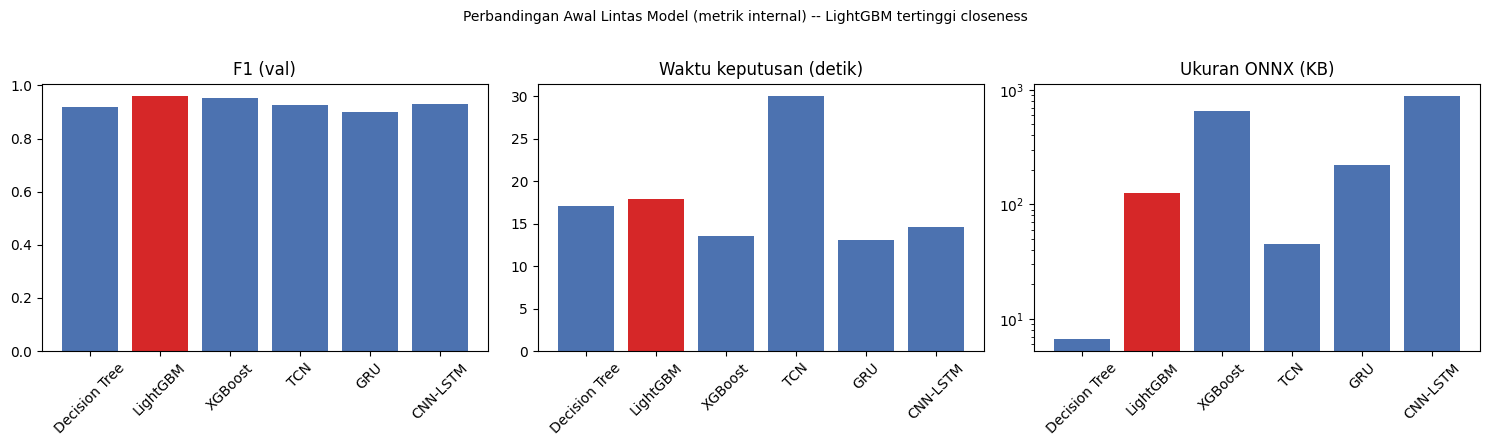

In [8]:
import matplotlib.pyplot as plt


def entropy_weight_topsis(df, criteria, senses):
    X = df[criteria].to_numpy(dtype=float)
    m, n = X.shape
    R = np.zeros_like(X)
    for j in range(n):
        col = X[:, j]
        lo, hi = col.min(), col.max()
        if hi == lo:
            R[:, j] = 1.0
        elif senses[j] == "+":
            R[:, j] = (col - lo) / (hi - lo)
        else:
            R[:, j] = (hi - col) / (hi - lo)
    P = R / R.sum(axis=0, keepdims=True)
    P_safe = np.where(P == 0, 1.0, P)
    e = -1.0 / np.log(m) * (P * np.log(P_safe)).sum(axis=0)
    w = (1.0 - e) / (1.0 - e).sum()
    V = R * w
    ideal_best, ideal_worst = V.max(axis=0), V.min(axis=0)
    dist_best = np.sqrt(((V - ideal_best) ** 2).sum(axis=1))
    dist_worst = np.sqrt(((V - ideal_worst) ** 2).sum(axis=1))
    out = df.copy()
    out["closeness"] = dist_worst / (dist_best + dist_worst)
    for j, c in enumerate(criteria):
        out[f"w_{c}"] = w[j]
    return out.sort_values("closeness", ascending=False)


print("=" * 70)
print("PERBANDINGAN AWAL LINTAS MODEL")
print("=" * 70)

cross_df = stage1_df[["model", "f1", "avg_time_s"]].merge(onnx_sizes_df[["model", "onnx_kb"]], on="model")

CRITERIA = ["f1", "avg_time_s", "onnx_kb"]
SENSES = ["+", "-", "-"]
F1_FLOOR_FRAC = 0.90
NEAR_MISS_MARGIN = 0.03

f1_max = cross_df["f1"].max()
f1_floor = F1_FLOOR_FRAC * f1_max
survivors = cross_df[cross_df.f1 >= f1_floor].reset_index(drop=True)
excluded = cross_df[cross_df.f1 < f1_floor].reset_index(drop=True)

ranked = entropy_weight_topsis(survivors, CRITERIA, SENSES)
w = ranked.iloc[0]

print(f"\nF1 maks={f1_max:.4f}, ambang {F1_FLOOR_FRAC:.0%}={f1_floor:.4f}, "
      f"lolos filter={len(survivors)}/{len(cross_df)}")
print(f"bobot entropi: f1={w.w_f1:.3f}  avg_time_s={w.w_avg_time_s:.3f}  onnx_kb={w.w_onnx_kb:.3f}")
print(ranked[["model", "f1", "avg_time_s", "onnx_kb", "closeness"]].to_string(index=False))
print(f"\nunggul metrik internal (SEMENTARA): {w.model} (closeness={w.closeness:.4f})")

cross_df.to_csv("/kaggle/working/nb4a_cross_model_preliminary.csv", index=False)
ranked.to_csv("/kaggle/working/nb4a_topsis_cross_model_preliminary.csv", index=False)
print("\nDisimpan: nb4a_cross_model_preliminary.csv, nb4a_topsis_cross_model_preliminary.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = [("f1", "F1 (val)", False), ("avg_time_s", "Waktu keputusan (detik)", False),
           ("onnx_kb", "Ukuran ONNX (KB)", True)]
colors = ["#d62728" if m == w.model else "#4c72b0" for m in cross_df["model"]]
for ax, (col, label, logscale) in zip(axes, metrics):
    ax.bar(cross_df["model"], cross_df[col], color=colors)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=45)
    if logscale:
        ax.set_yscale("log")
fig.suptitle(f"Perbandingan Awal Lintas Model (metrik internal) -- {w.model} tertinggi closeness\n", fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/nb4a_cross_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
